In [1]:
import sys
sys.path.insert(0, '..')
from dependencies import *

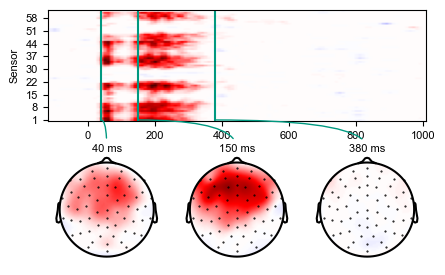

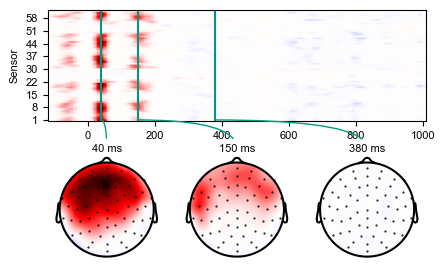

In [2]:
# SANITY CHECK

# Compare the TRFs we got with theirs
DATA_ROOT_OG = Path("~").expanduser()
SUBJECT = 'S15'
MODEL = 'envelope_log'

# Configure the matplotlib figure style
FONT = 'Arial'
FONT_SIZE = 8
RC = {
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.transparent': True,
    # Font
    'font.family': 'sans-serif',
    'font.sans-serif': FONT,
    'font.size': FONT_SIZE,
    'figure.labelsize': FONT_SIZE,
    'figure.titlesize': FONT_SIZE,
    'axes.labelsize': FONT_SIZE,
    'axes.titlesize': FONT_SIZE,
    'xtick.labelsize': FONT_SIZE,
    'ytick.labelsize': FONT_SIZE,    
    'legend.fontsize': FONT_SIZE,
}
plt.rcParams.update(RC)

trf = eelbrain.load.unpickle(TRF_DIR / SUBJECT / f'{SUBJECT} {MODEL}.pickle')
p = eelbrain.plot.TopoArray(trf.h_scaled, t=[0.040, 0.150, 0.380], clip='circle')

trf2 = eelbrain.load.unpickle(DATA_ROOT_OG / 'Data' / 'Alice' / 'TRFs' / SUBJECT / f'{SUBJECT} envelope.pickle')
p2 = eelbrain.plot.TopoArray(trf2.h_scaled, t=[0.040, 0.150, 0.380], clip='circle')


===== Subject S15 =====

-- Model: envelope_log --
Plotting topomap: Your TRF
Plotting topomap: Alice TRF


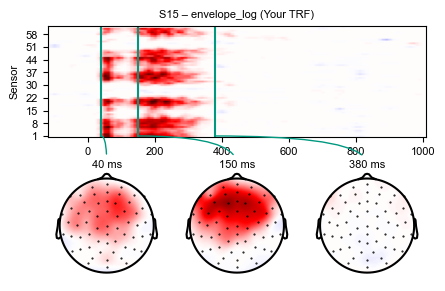

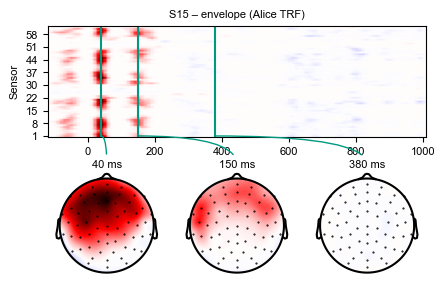

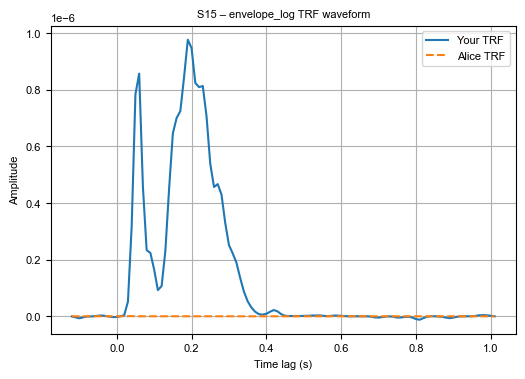


-- Model: envelope_onset --
Plotting topomap: Your TRF
Plotting topomap: Alice TRF


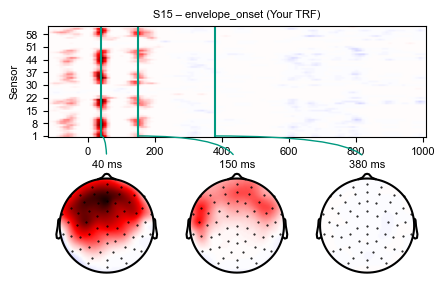

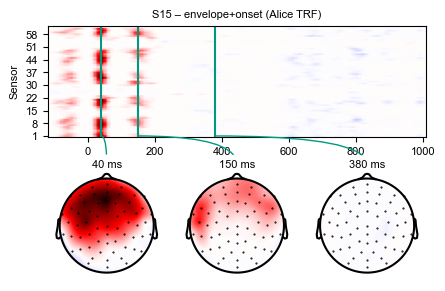

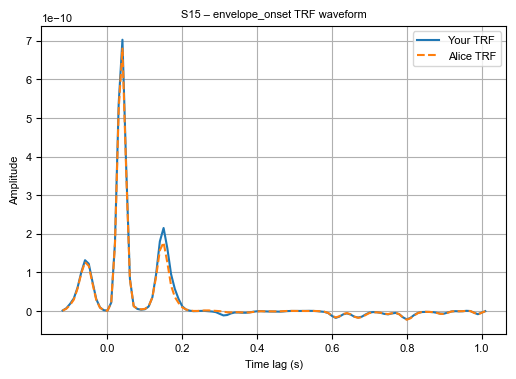


===== Subject S05 =====

-- Model: envelope_log --
Plotting topomap: Your TRF
Plotting topomap: Alice TRF


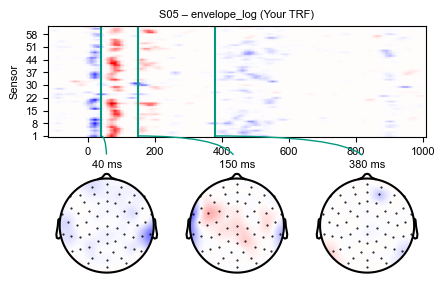

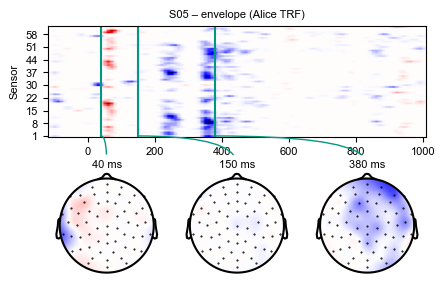

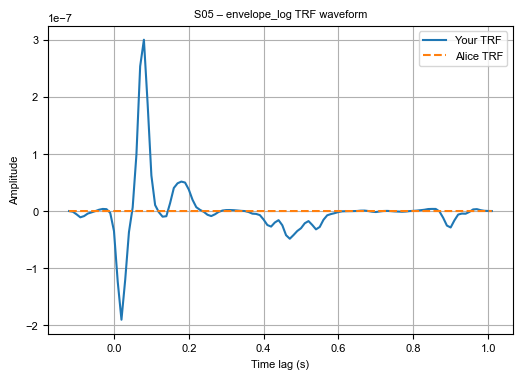


-- Model: envelope_onset --
Plotting topomap: Your TRF
Plotting topomap: Alice TRF


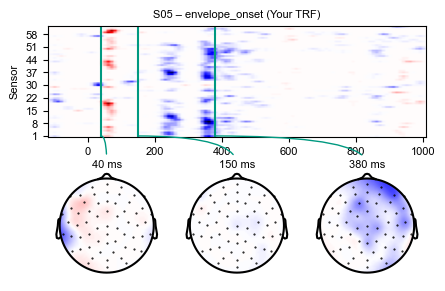

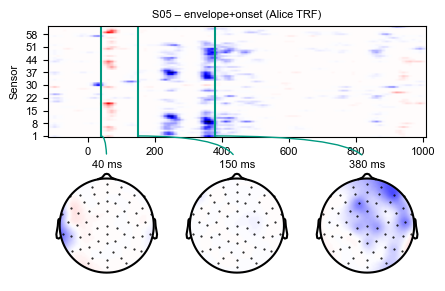

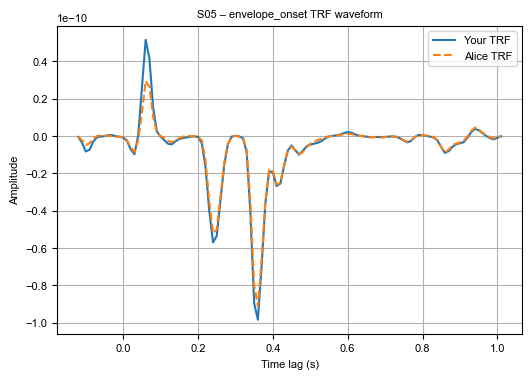


===== Subject S08 =====

-- Model: envelope_log --
Plotting topomap: Your TRF
Plotting topomap: Alice TRF


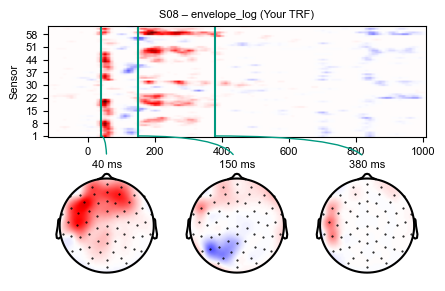

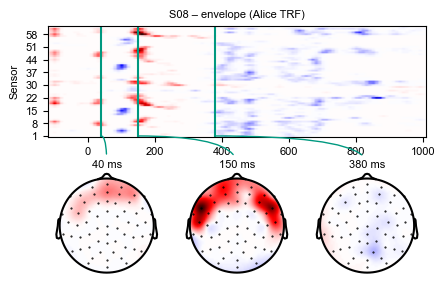

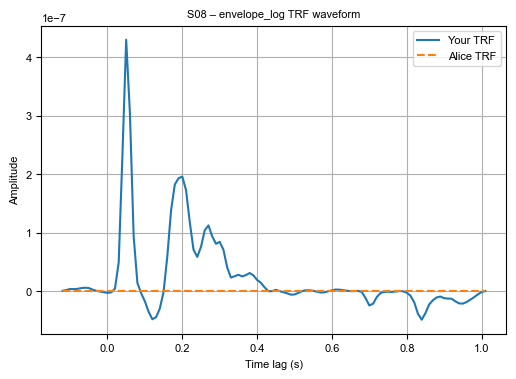


-- Model: envelope_onset --
Plotting topomap: Your TRF
Plotting topomap: Alice TRF


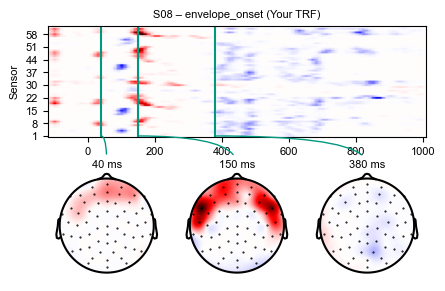

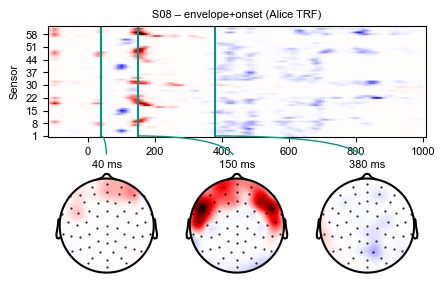

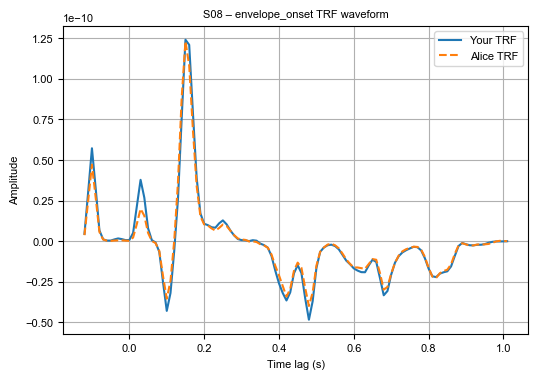

In [3]:
# -----------------------------
# CONFIG
# -----------------------------
subjects = ['S15', 'S05', 'S08']            # Subjects to check
models = ['envelope_log', 'envelope_onset'] # Your models
time_points = [0.040, 0.150, 0.380]        # Time points for topomap
DATA_ROOT_OG = Path("~").expanduser()       # Alice dataset root

# Map your models to the corresponding Alice TRF files
alice_mapping = {
    'envelope_log': 'envelope',
    'envelope_onset': 'envelope+onset'
}

# -----------------------------
# SANITY CHECK LOOP
# -----------------------------
for subject in subjects:
    print(f'\n===== Subject {subject} =====')

    for model in models:
        print(f'\n-- Model: {model} --')

        # -------------------------------
        # Load YOUR TRF
        trf_path = TRF_DIR / subject / f'{subject} {model}.pickle'
        trf = eelbrain.load.unpickle(trf_path)
        trf_h = getattr(trf, 'h_scaled', trf.h)
        if isinstance(trf_h, tuple):
            trf_h = trf_h[0]  # pick first predictor if multiple

        # -------------------------------
        # Load ALICE TRF
        alice_trf_file = alice_mapping[model]
        alice_trf_path = DATA_ROOT_OG / 'Data' / 'Alice' / 'TRFs' / subject / f'{subject} {alice_trf_file}.pickle'
        trf_alice = eelbrain.load.unpickle(alice_trf_path)
        trf_alice_h = getattr(trf_alice, 'h_scaled', trf_alice.h)
        if isinstance(trf_alice_h, tuple):
            trf_alice_h = trf_alice_h[0]

        # -------------------------------
        # Topomap: YOUR TRF
        print("Plotting topomap: Your TRF")
        eelbrain.plot.TopoArray(
            trf_h,
            t=time_points,
            clip='circle',
            axtitle=f'{subject} – {model} (Your TRF)'
        )

        # Topomap: ALICE TRF
        print("Plotting topomap: Alice TRF")
        eelbrain.plot.TopoArray(
            trf_alice_h,
            t=time_points,
            clip='circle',
            axtitle=f'{subject} – {alice_trf_file} (Alice TRF)'
        )

        # -------------------------------
        # Waveform: average over sensors (and predictors if exist)
        trf_wave = trf_h.mean('sensor')
        alice_wave = trf_alice_h.mean('sensor')

        if 'predictor' in trf_wave.dims:
            trf_wave = trf_wave.mean('predictor')
            alice_wave = alice_wave.mean('predictor')

        plt.figure(figsize=(6,4))
        plt.plot(trf_wave.time, trf_wave.x, label='Your TRF', color='C0')
        plt.plot(alice_wave.time, alice_wave.x, label='Alice TRF', color='C1', linestyle='--')
        plt.title(f'{subject} – {model} TRF waveform')
        plt.xlabel('Time lag (s)')
        plt.ylabel('Amplitude')
        plt.grid(True)
        plt.legend()
        plt.show()

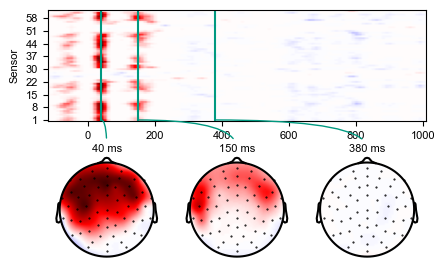

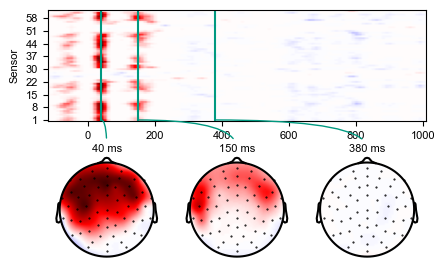

In [9]:
# SANITY CHECK

# Compare the TRFs we got with theirs
DATA_ROOT_OG = Path("~").expanduser()
SUBJECT, SENSOR = 'S15', '19'
STIMULUS = '1'
MODEL = 'envelope_onset'

# Configure the matplotlib figure style
FONT = 'Arial'
FONT_SIZE = 8
RC = {
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.transparent': True,
    # Font
    'font.family': 'sans-serif',
    'font.sans-serif': FONT,
    'font.size': FONT_SIZE,
    'figure.labelsize': FONT_SIZE,
    'figure.titlesize': FONT_SIZE,
    'axes.labelsize': FONT_SIZE,
    'axes.titlesize': FONT_SIZE,
    'xtick.labelsize': FONT_SIZE,
    'ytick.labelsize': FONT_SIZE,    
    'legend.fontsize': FONT_SIZE,
}
plt.rcParams.update(RC)

trf = eelbrain.load.unpickle(TRF_DIR / SUBJECT / f'{SUBJECT} {MODEL}.pickle')
p = eelbrain.plot.TopoArray(trf.h, t=[0.040, 0.150, 0.380], clip='circle')

trf2 = eelbrain.load.unpickle(DATA_ROOT_OG / 'Data' / 'Alice' / 'TRFs' / SUBJECT / f'{SUBJECT} envelope+onset.pickle')
p2 = eelbrain.plot.TopoArray(trf.h, t=[0.040, 0.150, 0.380], clip='circle')